In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Matplotlib is building the font cache; this may take a moment.


In [3]:
df= pd.read_csv('/Users/tarubprakash/Desktop/tarun/temp btp/processed_data_apoeres_3dec25.csv')

In [4]:
df.head()

,subject_id,visit,DIAGNOSIS_1.0,DIAGNOSIS_2.0,DIAGNOSIS_3.0,GENOTYPE_2/2,GENOTYPE_2/3,GENOTYPE_2/4,GENOTYPE_3/3,GENOTYPE_3/4,...,CDHOME_0.0,CDHOME_0.5,CDHOME_1.0,CDHOME_2.0,CDHOME_3.0,CDCARE_0.0,CDCARE_1.0,CDCARE_2.0,CDCARE_3.0,DIAGNOSIS
0,941_S_10002,m12,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
1,941_S_10002,m24,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
2,941_S_10002,sc,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
3,941_S_7074,m18,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,941_S_7074,m42,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [5]:
df.drop(columns=['subject_id', 'visit'], inplace=True)

In [7]:
only_diagnosis_df=df
categorical_cols=['DIAGNOSIS_1.0',	'DIAGNOSIS_2.0',	'DIAGNOSIS_3.0']
only_diagnosis_df.drop(columns=categorical_cols, inplace=True)
only_diagnosis_df.head()

,GENOTYPE_2/2,GENOTYPE_2/3,GENOTYPE_2/4,GENOTYPE_3/3,GENOTYPE_3/4,GENOTYPE_4/4,CDMEMORY_0.0,CDMEMORY_0.5,CDMEMORY_1.0,CDMEMORY_2.0,...,CDHOME_0.0,CDHOME_0.5,CDHOME_1.0,CDHOME_2.0,CDHOME_3.0,CDCARE_0.0,CDCARE_1.0,CDCARE_2.0,CDCARE_3.0,DIAGNOSIS
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [9]:
import pandas as pd
from ctgan import CTGAN  # from the `ctgan` library


def oversample_diagnosis_ctgan(
    df: pd.DataFrame,
    n_synthetic: int = 1000,
    target_col: str = "DIAGNOSIS",
    target_value=3.0,
    epochs: int = 300,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Use CTGAN to generate synthetic rows with DIAGNOSIS == 3.0 and
    append them to the original dataframe.

    Returns
    -------
    balanced_df : original df + synthetic rows
    synthetic_df : only the synthetic rows
    """

    # Columns you listed (treated as categorical / discrete)
    used_columns = [
        "GENOTYPE_2/2","GENOTYPE_2/3","GENOTYPE_2/4","GENOTYPE_3/3",
        "GENOTYPE_3/4","GENOTYPE_4/4",
        "CDMEMORY_0.0","CDMEMORY_0.5","CDMEMORY_1.0","CDMEMORY_2.0","CDMEMORY_3.0",
        "CDORIENT_0.0","CDORIENT_0.5","CDORIENT_1.0","CDORIENT_2.0","CDORIENT_3.0",
        "CDJUDGE_0.0","CDJUDGE_0.5","CDJUDGE_1.0","CDJUDGE_2.0","CDJUDGE_3.0",
        "CDCOMMUN_0.0","CDCOMMUN_0.5","CDCOMMUN_1.0","CDCOMMUN_2.0","CDCOMMUN_3.0",
        "CDHOME_0.0","CDHOME_0.5","CDHOME_1.0","CDHOME_2.0","CDHOME_3.0",
        "CDCARE_0.0","CDCARE_1.0","CDCARE_2.0","CDCARE_3.0",
        "DIAGNOSIS",
    ]

    # Work on a copy so we never mutate the caller's df
    data = df[used_columns].copy()
    # print(data.head())
    print("Training")
    # Treat all columns as discrete/categorical (CTGAN handles this)
    discrete_columns = used_columns

    # Initialise and train CTGAN
    ctgan = CTGAN(
        epochs=epochs,
        verbose=True,
    )
    ctgan.fit(data, discrete_columns=discrete_columns)
    print("generating")
    # Conditional sampling: force DIAGNOSIS ≈ target_value
    synthetic_df = ctgan.sample(
        n_synthetic,
        condition_column=target_col,
        condition_value=target_value,
    )

    # Ensure column order and types line up with original
    synthetic_df = synthetic_df[used_columns]
    synthetic_df = synthetic_df[synthetic_df["DIAGNOSIS"] == 3.0]
    # Combine original + synthetic
    balanced_df = pd.concat([df, synthetic_df], ignore_index=True)
    
    return balanced_df, synthetic_df


In [10]:
balanced_df, synthetic_3 = oversample_diagnosis_ctgan(only_diagnosis_df, n_synthetic=4900)

Training


Gen. (-00.90) | Discrim. (+00.14): 100%|██████████| 300/300 [06:18<00:00,  1.26s/it]


generating


In [11]:
print("Original DIAGNOSIS==3.0:", (only_diagnosis_df["DIAGNOSIS"] == 3.0).sum())
print("Synthetic DIAGNOSIS==3.0:", (synthetic_3["DIAGNOSIS"] == 3.0).sum())
print("New DIAGNOSIS==3.0:", (balanced_df["DIAGNOSIS"] == 3.0).sum())

Original DIAGNOSIS==3.0: 2351
Synthetic DIAGNOSIS==3.0: 1480
New DIAGNOSIS==3.0: 3831


In [13]:
balanced_df=pd.concat([synthetic_3, balanced_df], ignore_index=True)


In [12]:
print("3: ", (balanced_df["DIAGNOSIS"] == 3.0).sum())
print("2: ", (balanced_df["DIAGNOSIS"] == 2.0).sum())
print("1: ", (balanced_df["DIAGNOSIS"] == 1.0).sum())

3:  3831
2:  4730
1:  4227


In [13]:
balanced_df.to_csv("balanced_diagnosis_3.csv", index=False)


In [4]:
import pandas as pd
balanced_df=pd.read_csv('/Users/tarubprakash/Desktop/tarun/temp btp/balanced_diagnosis_3.csv')


In [5]:
balanced_df.head()

,GENOTYPE_2/2,GENOTYPE_2/3,GENOTYPE_2/4,GENOTYPE_3/3,GENOTYPE_3/4,GENOTYPE_4/4,CDMEMORY_0.0,CDMEMORY_0.5,CDMEMORY_1.0,CDMEMORY_2.0,...,CDHOME_0.0,CDHOME_0.5,CDHOME_1.0,CDHOME_2.0,CDHOME_3.0,CDCARE_0.0,CDCARE_1.0,CDCARE_2.0,CDCARE_3.0,DIAGNOSIS
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0


In [6]:
print((balanced_df['DIAGNOSIS']==1.0).sum())
print((balanced_df['DIAGNOSIS']==2.0).sum())
print((balanced_df['DIAGNOSIS']==3.0).sum())

4227
4730
4711


In [7]:

# balanced_df['DIAGNOSIS']=balanced_df["DIAGNOSIS"]==1.0
print((balanced_df['DIAGNOSIS']==1.0).sum())
print((balanced_df['DIAGNOSIS']==2.0).sum())
print((balanced_df['DIAGNOSIS']==0.0).sum())

4227
4730
0


In [8]:
def random_forest_kfold_evaluation(
    df,
    target_col="DIAGNOSIS",
    n_splits=5,
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    class_weight="balanced_subsample",
):
    """
    Stratified K-Fold cross-validation with RandomForestClassifier (multiclass).

    Prints:
      - Fold-wise confusion matrices and per-class metrics
      - Macro Precision/Recall/F1 mean and std across folds
      - Overall confusion matrix summed across folds

    Assumptions:
      - Feature columns are numeric (0.0/1.0)
      - target_col is multiclass (e.g. values in {1.0, 2.0, 3.0})
    """

    import numpy as np
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
    from sklearn.ensemble import RandomForestClassifier

    # --------- Prepare data ----------
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].astype(int).copy()  # ensure discrete labels

    labels = sorted(y.unique())  # e.g. [1, 2, 3]

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    all_prec, all_rec, all_f1 = [], [], []
    overall_cm = np.zeros((len(labels), len(labels)), dtype=int)

    fold_idx = 1
    for train_idx, test_idx in skf.split(X, y):
        print(f"\n========== Fold {fold_idx} ==========")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=random_state,
            n_jobs=-1,
            class_weight=class_weight,
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Confusion matrix for this fold
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        print("Confusion matrix (rows=true, cols=pred):")
        print("Labels:", labels)
        print(cm)
        overall_cm += cm

        # Per-class metrics
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test,
            y_pred,
            labels=labels,
            zero_division=0,
        )

        print("\nPer-class metrics:")
        for lab, p, r, f, s in zip(labels, precision, recall, f1, support):
            print(
                f"Class {lab}: "
                f"precision={p:.3f}, recall={r:.3f}, f1={f:.3f}, support={s}"
            )

        # Macro averages per fold
        all_prec.append(precision.mean())
        all_rec.append(recall.mean())
        all_f1.append(f1.mean())

        fold_idx += 1

    # --------- Summary ---------
    import numpy as np

    print("\n\n======= FINAL SUMMARY (RandomForest) =======")
    print("Average Macro Precision: {:.3f} ± {:.3f}".format(np.mean(all_prec), np.std(all_prec)))
    print("Average Macro Recall:    {:.3f} ± {:.3f}".format(np.mean(all_rec), np.std(all_rec)))
    print("Average Macro F1:        {:.3f} ± {:.3f}".format(np.mean(all_f1), np.std(all_f1)))

    print("\nOverall Confusion Matrix (summed across folds):")
    print("Labels:", labels)
    print(overall_cm)

    return {
        "labels": labels,
        "avg_precision": np.mean(all_prec),
        "avg_recall": np.mean(all_rec),
        "avg_f1": np.mean(all_f1),
        "overall_confusion_matrix": overall_cm,
    }


In [9]:
random_forest_kfold_evaluation(balanced_df)


========== Fold 1 ==========
Confusion matrix (rows=true, cols=pred):
Labels: [np.int64(1), np.int64(2), np.int64(3)]
[[772  72   1]
 [ 68 820  58]
 [  2  85 856]]

Per-class metrics:
Class 1: precision=0.917, recall=0.914, f1=0.915, support=845
Class 2: precision=0.839, recall=0.867, f1=0.853, support=946
Class 3: precision=0.936, recall=0.908, f1=0.921, support=943

========== Fold 2 ==========
Confusion matrix (rows=true, cols=pred):
Labels: [np.int64(1), np.int64(2), np.int64(3)]
[[795  50   1]
 [ 80 810  56]
 [  3 105 834]]

Per-class metrics:
Class 1: precision=0.905, recall=0.940, f1=0.922, support=846
Class 2: precision=0.839, recall=0.856, f1=0.848, support=946
Class 3: precision=0.936, recall=0.885, f1=0.910, support=942

========== Fold 3 ==========
Confusion matrix (rows=true, cols=pred):
Labels: [np.int64(1), np.int64(2), np.int64(3)]
[[785  58   3]
 [ 76 793  77]
 [  0  94 848]]

Per-class metrics:
Class 1: precision=0.912, recall=0.928, f1=0.920, support=846
Class 2: pr

{'labels': [np.int64(1), np.int64(2), np.int64(3)],
 'avg_precision': np.float64(0.8931034276586061),
 'avg_recall': np.float64(0.8931505618174235),
 'avg_f1': np.float64(0.8929629664776814),
 'overall_confusion_matrix': array([[3922,  300,    5],
        [ 376, 4023,  331],
        [   7,  459, 4245]])}

In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
)
# Model Imports
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

def kfold_evaluation(
    df,
    model_name: str, # NEW: Identifier for the model
    params: dict,    # Parameters specific to the model
    target_col="DIAGNOSIS",
    n_splits=5,
    random_state=42,
    verbose=False
):
    """
    Run Stratified K-Fold cross-validation for a specified model 
    and return the aggregated metrics.
    """
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].astype(int).copy()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    all_prec, all_rec, all_f1 = [], [], []
    overall_cm = np.zeros((3, 3), dtype=int) # Assuming 3 classes: [1, 2, 3]

    # --- Dynamic Model Instantiation ---
    if model_name == 'CatBoost':
        # CatBoost uses 'iterations', 'learning_rate', 'depth'
        model = CatBoostClassifier(
            loss_function="MultiClass",
            random_seed=random_state,
            verbose=verbose,
            **params 
        )
    elif model_name == 'LightGBM':
        # LightGBM uses 'n_estimators', 'learning_rate', 'max_depth'
        model = LGBMClassifier(
            objective='multiclass', 
            n_jobs=-1, 
            random_state=random_state, 
            verbose=-1, # Suppress verbosity
            **params
        )
    elif model_name == 'XGBoost':
        # === FIX: Subtract 1 from target classes for XGBoost ===
        y = y - 1 # y is now [0, 1, 2] for the duration of this XGBoost run!
        
        # XGBoost uses 'n_estimators', 'learning_rate', 'max_depth', 'num_class'
        model = XGBClassifier(
            objective='multi:softmax', 
            eval_metric='mlogloss',   
            use_label_encoder=False, 
            n_jobs=-1, 
            random_state=random_state, 
            num_class=len(y.unique()), # num_class is now correctly 3 for [0, 1, 2]
            **params
        )
    elif model_name == 'RandomForest':
        # RandomForest uses 'n_estimators', 'max_depth'
        model = RandomForestClassifier(
            random_state=random_state, 
            n_jobs=-1,
            **params
        )
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    # --- K-Fold Training and Evaluation Loop ---
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        
        # Random Forest and XGBoost predict directly as arrays, 
        # CatBoost needs .flatten()
        y_pred = model.predict(X_test)
        if model_name == 'CatBoost':
            y_pred = y_pred.flatten()
        if model_name == 'XGBoost':
            y_test_metrics = y_test + 1
            y_pred_metrics = y_pred + 1
        else:
            y_test_metrics = y_test
            y_pred_metrics = y_pred
        # Calculate metrics
        cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])
        overall_cm += cm

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, labels=[1, 2, 3], zero_division=0
        )
        
        all_prec.append(precision.mean())
        all_rec.append(recall.mean())
        all_f1.append(f1.mean())

    # Calculate final metrics
    return {
        "avg_precision": np.mean(all_prec),
        "std_precision": np.std(all_prec),
        "avg_recall": np.mean(all_rec),
        "std_recall": np.std(all_rec),
        "avg_f1": np.mean(all_f1),
        "std_f1": np.std(all_f1),
        "overall_confusion_matrix": overall_cm,
    }

# NOTE: Keep the original log_to_mongodb function as it is.
# (It was defined in the previous response and doesn't need changes.)

In [61]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold # New Import for K-CV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, VotingClassifier # Added VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from typing import Tuple, List

# --- 1. Define Best Hyperparameters from Grid Search ---

# FIX: Added 'min_gain_to_split' and 'verbose: -1' to completely suppress LightGBM warnings
BEST_LGBM_PARAMS = {
    'learning_rate': 0.05,
    'max_depth': 5,
    'n_estimators': 100,
    'random_state': 42,
    'n_jobs': -1,
    'objective': 'multiclass',
    'min_child_samples': 20, # Increased for more robust splits
    'max_bin': 2,             # Recommended for binary features (0/1)
    'min_gain_to_split': 0.1, # Requires a minimum gain of 0.1 to attempt a split
    'verbose': -1             # <-- Suppresses ALL output, including warnings
}

BEST_CATBOOST_PARAMS = {
    'depth': 4,
    'iterations': 300,
    'learning_rate': 0.05,
    'random_state': 42,
    'verbose': 0, # Suppress training output
    'loss_function': 'MultiClass'
}

def prepare_data_for_stacking(
    df: pd.DataFrame, 
    target_col: str = 'DIAGNOSIS'
) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Prepares features (X) and target (y) from the input DataFrame and applies 
    0-indexing transformation (1, 2, 3 -> 0, 1, 2). 
    The function now returns the full dataset for K-Fold Cross-Validation.
    
    Args:
        df (pd.DataFrame): The input DataFrame containing features and the target.
        target_col (str): The name of the target column (e.g., 'DIAGNOSIS').
        
    Returns:
        tuple: (X_full, y_full_transformed)
    """
    if df is None or df.empty:
        print("Error: Input DataFrame is empty or None.")
        return pd.DataFrame(), pd.Series(dtype='int')

    # Separate target and features
    if target_col not in df.columns:
        print(f"Error: Target column '{target_col}' not found in DataFrame.")
        return pd.DataFrame(), pd.Series(dtype='int')

    y = df[target_col].copy()
    X = df.drop(columns=[target_col]).copy()
    
    # --- CRITICAL TRANSFORMATION ---
    # Convert labels 1, 2, 3 to 0, 1, 2 for boosting models.
    y_transformed = y.astype(int) - 1
    
    print(f"Original Target unique values (in df): {np.sort(y.unique())}")
    print(f"Transformed Target unique values (used for training): {np.sort(y_transformed.unique())}")
    print(f"Full dataset size: {len(X)} samples.")
    
    return X, y_transformed

def create_voting_model() -> VotingClassifier:
    """
    Defines the architecture of the Voting Classifier using base models.
    
    This ensemble now uses Soft Voting (averaging predicted probabilities) which is 
    generally more robust and handles prediction array consistency better.
    """
    # Base Estimators
    lgbm_model = LGBMClassifier(**BEST_LGBM_PARAMS)
    catboost_model = CatBoostClassifier(**BEST_CATBOOST_PARAMS)

    estimators = [
        ('lgbm', lgbm_model),
        ('catboost', catboost_model)
    ]

    # Voting Classifier
    # FIX: Switched to 'soft' voting to resolve the ValueError.
    # Soft voting requires base models to support predict_proba.
    voting_clf = VotingClassifier(
        estimators=estimators, 
        voting='soft', 
        n_jobs=-1
    )
    return voting_clf

def evaluate_with_kfold(X_full: pd.DataFrame, y_full: pd.Series, n_splits: int = 5):
    """
    Performs K-Fold Cross-Validation evaluation of the entire Voting Classifier pipeline.
    
    Args:
        X_full (pd.DataFrame): Full feature set.
        y_full (pd.Series): Full target set (0-indexed).
        n_splits (int): Number of folds for K-CV.
    """
    
    # Check if data is valid
    if X_full.empty or y_full.empty:
        print("Cannot evaluate: Data is empty.")
        return
    
    # Initialize Stratified K-Fold Cross-Validation
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Lists to store metrics for each fold
    accuracy_scores: List[float] = []
    f1_scores: List[float] = []
    
    print(f"\n--- Starting {n_splits}-Fold Stratified Cross-Validation Evaluation ---")
    
    for fold, (train_index, test_index) in enumerate(skf.split(X_full, y_full)):
        X_train, X_test = X_full.iloc[train_index], X_full.iloc[test_index]
        y_train, y_test = y_full.iloc[train_index], y_full.iloc[test_index]
        
        # 1. Create the Voting Model
        ensemble_clf = create_voting_model() # Changed from stacking_clf to ensemble_clf
        
        # 2. Train the Model for this fold
        print(f"Training Fold {fold + 1}/{n_splits}...")
        ensemble_clf.fit(X_train, y_train)
        
        # 3. Predict and Collect Metrics
        y_pred = ensemble_clf.predict(X_test)
        
        fold_accuracy = accuracy_score(y_test, y_pred)
        # Using 'micro' for F1 to be consistent with overall accuracy
        fold_f1 = f1_score(y_test, y_pred, average='micro') 
        
        accuracy_scores.append(fold_accuracy)
        f1_scores.append(fold_f1)
        
        print(f"Fold {fold + 1} Complete. Accuracy: {fold_accuracy:.4f}, F1-Score (Micro): {fold_f1:.4f}")
        
        # Print detailed report for the first fold as an example
    
        print("\n--- Detailed Classification Report for Fold 1 (Labels 0, 1, 2) ---")
        print(classification_report(
            y_test, 
            y_pred, 
            target_names=['Class 1 (0)', 'Class 2 (1)', 'Class 3 (2)']
        ))
        print("--- Confusion Matrix for Fold 1 ---")
        print(confusion_matrix(y_test, y_pred))

    # --- 4. Report Final Aggregated Results ---
    print("\n--- Final K-Fold CV Results (Mean ± Std Dev) ---")
    print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
    print(f"Average F1-Score (Micro): {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    
    # Return the aggregated metrics
    return np.mean(accuracy_scores), np.mean(f1_scores)


if __name__ == '__main__':
    
    
    
    print("Simulated ADNI DataFrame loaded and structured.")
    # ---------------------------------------------

    # 2. Prepare full Data (no internal split)
    X_full, y_full = prepare_data_for_stacking(balanced_df, target_col='DIAGNOSIS')
    
    # 3. Evaluate the Voting Model using K-Fold Cross-Validation
    if not X_full.empty:
        evaluate_with_kfold(X_full, y_full, n_splits=5)

Simulated ADNI DataFrame loaded and structured.
Original Target unique values (in df): [1. 2. 3.]
Transformed Target unique values (used for training): [0 1 2]
Full dataset size: 13668 samples.

--- Starting 5-Fold Stratified Cross-Validation Evaluation ---
Training Fold 1/5...
Fold 1 Complete. Accuracy: 0.9009, F1-Score (Micro): 0.9009

--- Detailed Classification Report for Fold 1 (Labels 0, 1, 2) ---
              precision    recall  f1-score   support

 Class 1 (0)       0.91      0.92      0.92       845
 Class 2 (1)       0.86      0.86      0.86       946
 Class 3 (2)       0.93      0.93      0.93       943

    accuracy                           0.90      2734
   macro avg       0.90      0.90      0.90      2734
weighted avg       0.90      0.90      0.90      2734

--- Confusion Matrix for Fold 1 ---
[[775  70   0]
 [ 67 813  66]
 [  5  63 875]]
Training Fold 2/5...
Fold 2 Complete. Accuracy: 0.8958, F1-Score (Micro): 0.8958

--- Detailed Classification Report for Fold 1 (L

In [98]:
!pip install -y scikit-learn imbalanced-learn
!python -c "import sklearn, imblearn; print('sklearn:', sklearn.__version__, 'imblearn:', imblearn.__version__)"


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y
sklearn: 1.7.2 imblearn: 0.14.0


In [93]:
from imblearn.over_sampling import SMOTE



ImportError: cannot import name '_fit_context' from 'sklearn.base' (/usr/local/lib/python3.11/dist-packages/sklearn/base.py)

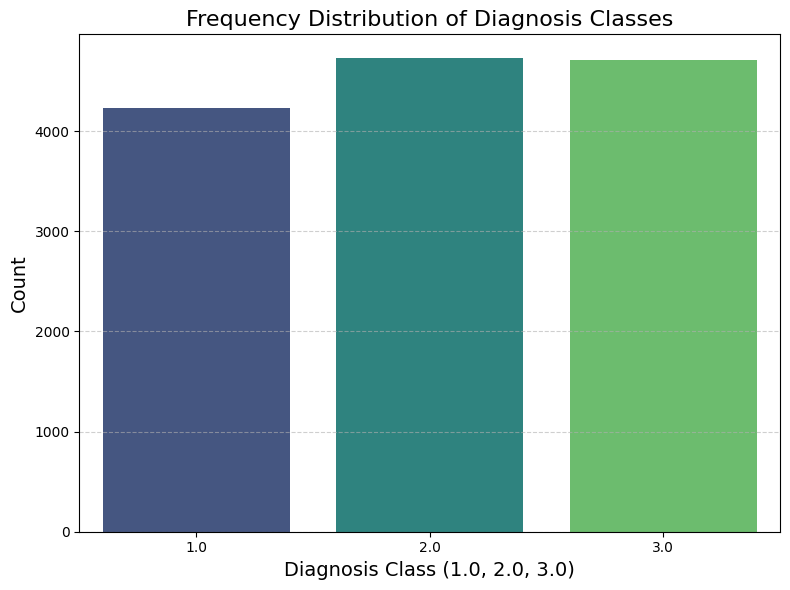


LDA Explained Variance Ratio:
  Component 1: 0.7737
  Component 2: 0.2263
  Total: 1.0000


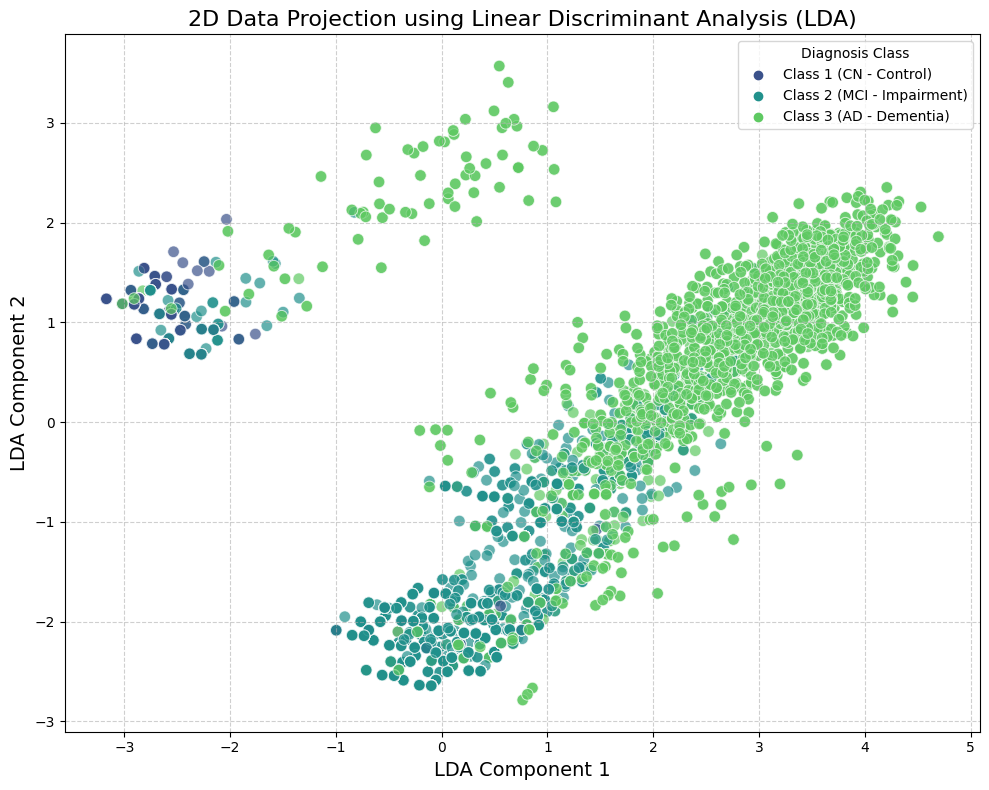

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from typing import Optional, Dict

def plot_lda_projection(
    df: pd.DataFrame, 
    target_col: str = 'DIAGNOSIS',
    title: str = '2D Data Projection using Linear Discriminant Analysis (LDA)',
    target_map: Optional[Dict[int, str]] = None
) -> None:
    """
    Applies LDA to a DataFrame to reduce dimensionality to 2 components and 
    plots the resulting data points colored by the target class.

    Args:
        df (pd.DataFrame): Input DataFrame containing features and the target column.
        target_col (str): The name of the target column (e.g., 'DIAGNOSIS').
        title (str): The title for the scatter plot.
        target_map (Dict[int, str], optional): A mapping from original class 
            numbers (1, 2, 3) to descriptive labels for the legend.
    """
    
    if df is None or df.empty:
        print("Error: Input DataFrame is empty or None.")
        return

    if target_col not in df.columns:
        print(f"Error: Target column '{target_col}' not found in DataFrame.")
        return

    # 1. Prepare Data
    # Separate features (X) and original target labels (y_original)
    y_original = df[target_col].copy().astype(int)
    X_full = df.drop(columns=[target_col]).copy()
    
    # Check if the number of features is sufficient for LDA (must be > C-1)
    n_features = X_full.shape[1]
    n_classes = y_original.nunique()
    if n_features < (n_classes - 1):
        print(f"LDA requires at least {n_classes - 1} features. Found {n_features}.")
        return

    # Convert original labels (1, 2, 3) to 0-indexed labels (0, 1, 2) for LDA
    y_lda = y_original - 1 
    
    # Define default map if not provided
    if target_map is None:
        target_map = {
            1: 'Class 1.0', 
            2: 'Class 2.0', 
            3: 'Class 3.0'
        }

    # 2. Apply LDA
    # n_components is set to 2 (C-1 for 3 classes) to allow 2D plotting
    try:
        lda = LDA(n_components=2)
        X_lda = lda.fit_transform(X_full, y_lda)
        
        # Check the amount of variance explained by the components
        explained_variance = lda.explained_variance_ratio_
        print(f"\nLDA Explained Variance Ratio:")
        print(f"  Component 1: {explained_variance[0]:.4f}")
        print(f"  Component 2: {explained_variance[1]:.4f}")
        print(f"  Total: {np.sum(explained_variance):.4f}")

    except Exception as e:
        print(f"Error during LDA transformation: {e}")
        return

    # 3. Create Plotting DataFrame
    df_lda = pd.DataFrame(data=X_lda, columns=['LDA Component 1', 'LDA Component 2'])
    
    # Map the original class labels back for the legend
    df_lda['DIAGNOSIS'] = y_original.map(target_map).astype('category')

    # 4. Generate Scatter Plot
    plt.figure(figsize=(10, 8))
    
    # Use seaborn for easy classification coloring
    sns.scatterplot(
        x='LDA Component 1', 
        y='LDA Component 2', 
        hue='DIAGNOSIS', 
        data=df_lda,
        palette=sns.color_palette("viridis", n_colors=n_classes),
        s=70, # size of points
        alpha=0.7
    )

    plt.title(title, fontsize=16)
    plt.xlabel('LDA Component 1', fontsize=14)
    plt.ylabel('LDA Component 2', fontsize=14)
    plt.legend(title='Diagnosis Class', loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # --- DEMONSTRATION: SIMULATED DATA ---
    np.random.seed(42)
    
    # Define the mapping for clear legend labels (assuming ADNI style labels)
    adni_map = {
        1: 'Class 1 (CN - Control)', 
        2: 'Class 2 (MCI - Impairment)', 
        3: 'Class 3 (AD - Dementia)'
    }
    
    # --- NEW: Plot Frequency of Diagnosis ---
    plt.figure(figsize=(8, 6))
    sns.countplot(x='DIAGNOSIS', data=balanced_df, palette='viridis', order=sorted(balanced_df['DIAGNOSIS'].unique()))
    plt.title('Frequency Distribution of Diagnosis Classes', fontsize=16)
    plt.xlabel('Diagnosis Class (1.0, 2.0, 3.0)', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    # ---------------------------------------
    
    # Call the plotting function for LDA projection
    plot_lda_projection(
        df=balanced_df,
        target_map=adni_map
    )
    
    # --- END OF DEMONSTRATION ---

In [1]:
import pandas as pd
balanced_df=pd.read_csv('/kaggle/input/adni-dataset/balanced_diagnosis_3.csv')

In [ ]:
import numpy as np
import pandas as pd
import pickle # For model serialization
import json
from typing import Tuple, List, Dict, Any, Optional

# --- MONGODB IMPORTS ---
from pymongo import MongoClient
from bson import json_util 
# -----------------------

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# --- IMPORTS FOR DIMENSIONALITY REDUCTION ---
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline 

# --- 0. MONGODB CONFIGURATION (PLACEHOLDERS) ---
# NOTE: Update these with your actual connection details!
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("MONGODB_ATLAS_CLUSTER_URI")
MONGO_URI = secret_value_0 
DB_NAME = "ml_experiments_with_different_pca"
COLLECTION_NAME = "ensemble_grid_search"
# -----------------------------------------------

def log_to_mongodb(
    connection_string: str, 
    db_name: str, 
    collection_name: str, 
    experiment_data: dict
):
    """
    Connects to MongoDB and saves the experiment results, correctly handling
    non-standard types like numpy.
    """
    client = None # Initialize client outside try block
    try:
        # Connect to MongoDB
        client = MongoClient(connection_string)
        db = client[db_name]
        collection = db[collection_name]
        
        # --- FIX: Use json_util to serialize NumPy types ---
        # 1. Use json_util.dumps() to convert NumPy types (like int64, ndarray) 
        #    into a JSON string with MongoDB-friendly representations (like $numberLong).
        json_string = json_util.dumps(experiment_data)
        
        # 2. Use json.loads() to convert the JSON string back into a standard Python dict
        #    ready for PyMongo insertion.
        insert_data = json.loads(json_string)
        
        # Insert the document
        insert_result = collection.insert_one(insert_data)
        
        # Use simple print for logging inside the inner loop
        print(f"  --> ✅ Logged: PCA n={experiment_data['n_components']}, Weights ({experiment_data['lgbm_weight']},{experiment_data['catboost_weight']}), F1={experiment_data['mean_f1_score']:.4f}")
        
    except Exception as e:
        print(f"  --> ❌ ERROR logging to MongoDB: {e}")
    finally:
        # Close the connection
        if client:
            client.close()

def load_completed_experiments(connection_string: str, db_name: str, collection_name: str) -> set:
    """
    Connects to MongoDB and retrieves a set of completed experiment keys
    to enable skipping during grid search.
    The key is: (n_components, lgbm_weight, catboost_weight)
    """
    client = None
    completed_runs = set()
    try:
        client = MongoClient(connection_string)
        db = client[db_name]
        collection = db[collection_name]
        
        # Query for all completed runs and extract the unique key
        # We need to explicitly convert float weights to tuples for the set key
        for doc in collection.find({}, {'n_components': 1, 'lgbm_weight': 1, 'catboost_weight': 1, '_id': 0}):
            key = (doc['n_components'], doc['lgbm_weight'], doc['catboost_weight'])
            completed_runs.add(key)
        
        print(f"Loaded {len(completed_runs)} completed runs from MongoDB to skip.")
        return completed_runs
    except Exception as e:
        print(f"❌ ERROR loading completed experiments from MongoDB: {e}. Starting from scratch.")
        return set()
    finally:
        if client:
            client.close()

# --- 1. Define Best Hyperparameters from Grid Search ---

# FIX: Added 'min_gain_to_split' and 'verbose: -1' to completely suppress LightGBM warnings
BEST_LGBM_PARAMS = {
    'learning_rate': 0.05,
    'max_depth': 5,
    'n_estimators': 100,
    'random_state': 42,
    'n_jobs': 1, # Set to 1 to avoid conflicts with outer CV parallelization
    'objective': 'multiclass',
    'min_child_samples': 20,
    'max_bin': 2,
    'min_gain_to_split': 0.1,
    'verbose': -1
}

BEST_CATBOOST_PARAMS = {
    'depth': 4,
    'iterations': 300,
    'learning_rate': 0.05,
    'random_state': 42,
    'verbose': 0,
    'loss_function': 'MultiClass'
}

def create_pca_pipeline(estimator: Any, n_components: int) -> Pipeline:
    """
    Creates a scikit-learn Pipeline that applies PCA with the specified number
    of components, followed by the given classifier estimator.
    """
    pca = PCA(n_components=n_components)
    
    # Pipeline ensures PCA is fit only on the training data within each CV fold
    pipeline = Pipeline(steps=[
        ('pca', pca),
        ('classifier', estimator)
    ])
    return pipeline

def prepare_data_for_stacking(
    df: pd.DataFrame, 
    target_col: str = 'DIAGNOSIS'
) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Prepares features (X) and target (y) from the input DataFrame and applies 
    0-indexing transformation (1, 2, 3 -> 0, 1, 2). 
    """
    if df is None or df.empty:
        print("Error: Input DataFrame is empty or None.")
        return pd.DataFrame(), pd.Series(dtype='int')

    if target_col not in df.columns:
        print(f"Error: Target column '{target_col}' not found in DataFrame.")
        return pd.DataFrame(), pd.Series(dtype='int')

    y = df[target_col].copy()
    X = df.drop(columns=[target_col]).copy()
    
    # Convert labels 1, 2, 3 to 0, 1, 2 for boosting models.
    y_transformed = y.astype(int) - 1
    
    print(f"Full dataset size: {len(X)} samples.")
    
    return X, y_transformed

def create_voting_model(weights: Optional[List[float]] = None, n_components: int = 3) -> VotingClassifier:
    """
    Defines the architecture of the Voting Classifier using base models,
    now wrapped in a PCA Pipeline with n_components.
    
    NOTE: Includes user's requested GPU task types.
    """
    if weights is None:
        weights = [1.0, 1.0] # Default to equal weights
        
    # Base Estimators (Amplified Class Weighting)
    lgbm_model = LGBMClassifier(**BEST_LGBM_PARAMS, class_weight='balanced', device='gpu')
    # Use amplified weights for CatBoost
    catboost_model = CatBoostClassifier(**BEST_CATBOOST_PARAMS, class_weights=[1.0, 5.0, 1.0], task_type='GPU')  

    # --- WRAP BASE MODELS IN PCA PIPELINE ---
    estimators = [
        ('lgbm_pca', create_pca_pipeline(lgbm_model, n_components)),
        ('catboost_pca', create_pca_pipeline(catboost_model, n_components))
    ]
    # ----------------------------------------

    # Voting Classifier using soft voting
    voting_clf = VotingClassifier(
        estimators=estimators, 
        voting='soft', 
        n_jobs=1, # Setting n_jobs=1 to avoid the parallelization error
        weights=weights 
    )
    return voting_clf

def create_stacking_model(n_components: int = 3) -> StackingClassifier:
    """
    Defines the architecture of the Stacking Classifier using PCA-wrapped
    LGBM and CatBoost as base estimators.
    
    NOTE: Includes user's requested GPU task types.
    """
    # Level 0 Base Estimators (Amplified Class Weighting)
    estimators = [
        # --- WRAP BASE MODELS IN PCA PIPELINE ---
        ('lgbm_pca', create_pca_pipeline(LGBMClassifier(**BEST_LGBM_PARAMS, class_weight='balanced', device='gpu'), n_components)), 
        ('catboost_pca', create_pca_pipeline(CatBoostClassifier(**BEST_CATBOOST_PARAMS, class_weights=[1.0, 5.0, 1.0], task_type='GPU'), n_components))
        # ----------------------------------------
    ]
    
    # Level 1 Meta-Model (Learns how to combine base predictions)
    meta_model = LogisticRegression(solver='lbfgs', multi_class='multinomial', max_iter=1000, random_state=42)
    
    # Stacking Classifier
    stacking_clf = StackingClassifier(
        estimators=estimators,
        final_estimator=meta_model,
        cv=15, 
        n_jobs=1 
    )
    return stacking_clf

def evaluate_with_kfold(
    X_full: pd.DataFrame, 
    y_full: pd.Series, 
    n_splits: int = 5,
    weights: Optional[List[float]] = None,
    ensemble_type: str = 'voting',
    n_components: int = 3, # New argument for PCA components
    show_details: bool = False # Flag to control report verbosity
) -> Tuple[float, float]:
    """
    Performs K-Fold Cross-Validation evaluation of the chosen ensemble pipeline.
    """
    
    if X_full.empty or y_full.empty:
        return 0.0, 0.0
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    accuracy_scores: List[float] = []
    f1_scores: List[float] = []
    
    weights_display = weights if weights else [1, 1]
    title = f"{ensemble_type.capitalize()} (PCA n={n_components}, LGBM={weights_display[0]}, CatBoost={weights_display[1]})"
    
    # Only print full title for runs where details are shown (or the stacking model)
    if show_details or ensemble_type == 'stacking':
        print(f"\n--- Starting {title} ({n_splits}-Fold CV) ---")
    
    for fold, (train_index, test_index) in enumerate(skf.split(X_full, y_full)):
        X_train, X_test = X_full.iloc[train_index], X_full.iloc[test_index]
        y_train, y_test = y_full.iloc[train_index], y_full.iloc[test_index]
        
        X_train_final, y_train_final = X_train, y_train
        
        # 1. Create the appropriate Ensemble Model, passing n_components
        if ensemble_type == 'voting':
            ensemble_clf = create_voting_model(weights=weights, n_components=n_components)
        elif ensemble_type == 'stacking':
            ensemble_clf = create_stacking_model(n_components=n_components)
        else:
            raise ValueError("Invalid ensemble_type")

        # 2. Train the Model (Pipeline handles PCA fitting)
        ensemble_clf.fit(X_train_final, y_train_final)
        
        # 3. Predict and Collect Metrics
        y_pred = ensemble_clf.predict(X_test)
        
        fold_accuracy = accuracy_score(y_test, y_pred)
        fold_f1 = f1_score(y_test, y_pred, average='micro') 
        
        accuracy_scores.append(fold_accuracy)
        f1_scores.append(fold_f1)
        
        # Only print detailed report if explicitly requested 
        if fold == 0 and show_details:
            print(f"Fold 1 Complete. Accuracy: {fold_accuracy:.4f}, F1-Score (Micro): {fold_f1:.4f}")
            print("\n--- Detailed Classification Report for Fold 1 (Labels 0, 1, 2) ---")
            print(classification_report(
                y_test, 
                y_pred, 
                target_names=['Class 1 (0)', 'Class 2 (1)', 'Class 3 (2)']
            ))
            print("--- Confusion Matrix for Fold 1 ---")
            print(confusion_matrix(y_test, y_pred))
            
    # --- 4. Report Final Aggregated Results ---
    mean_acc = np.mean(accuracy_scores)
    mean_f1 = np.mean(f1_scores)
    
    if show_details or ensemble_type == 'stacking':
        print(f"  -> Mean F1-Score: {mean_f1:.4f} (Acc: {mean_acc:.4f})")
    
    return mean_acc, mean_f1

def train_and_save_best_model(X_full: pd.DataFrame, y_full: pd.Series, best_weights: List[float], best_n_components: int):
    """
    Trains the final Voting Classifier using the best weights and best PCA component count
    on the entire dataset and saves the model object to a pickle file.
    """
    print(f"\n\n--- Training Final Voting Model (PCA n={best_n_components}, LGBM={best_weights[0]}, CatBoost={best_weights[1]}) on Full Dataset ---")
    
    # 1. Create the final Voting Classifier with the optimal weights and components
    final_model = create_voting_model(weights=best_weights, n_components=best_n_components)
    
    # 2. Train the model on all available data
    final_model.fit(X_full, y_full)
    
    # 3. Serialize the model to a file
    filename = f'best_voting_classifier_pca_{best_n_components}_w_{best_weights[0]:.2f}_{best_weights[1]:.2f}.pkl'
    filename = filename.replace('.', 'p') # Replace decimals for valid filename
    try:
        with open(filename, 'wb') as file:
            pickle.dump(final_model, file)
        print(f"✅ Success: Final model saved to '{filename}'")
    except Exception as e:
        print(f"❌ Error saving model: {e}")


def run_ensemble_optimization(X_full: pd.DataFrame, y_full: pd.Series):
    """
    Runs a nested grid search to find the best combination of PCA components
    and Voting Classifier weights for the Weighted Soft Voting ensemble,
    skipping combinations that have already been logged to MongoDB.
    """
    print("\n\n#####################################################")
    print("### Starting Ensemble Optimization Run (with PCA) ###")
    print("#####################################################")
    
    # 1. Load completed experiments from MongoDB
    completed_runs = load_completed_experiments(MONGO_URI, DB_NAME, COLLECTION_NAME)

    # 2. Define the search space
    n_features = X_full.shape[1]
    n_components_range = range(3, n_features - 1) 
    
    if n_features < 5:
        print(f"Error: Not enough features ({n_features}) to run PCA optimization in the range [3, n_features-2].")
        return
        
    # Weights grid: Finer tuning around the 1.0 mark
    weight_values = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0] 
    weight_combinations = [[w1, w2] for w1 in weight_values for w2 in weight_values]
    
    print(f"PCA Range: {min(n_components_range)} to {max(n_components_range)}")
    print(f"Testing {len(weight_combinations)} weight combinations for each PCA component count.")

    # 3. Initialization for tracking the overall best result
    best_weights: List[float] = []
    best_f1: float = -1.0
    best_n_components: int = 0
    
    # Retrieve all results (including those loaded from DB) for the final summary
    all_results: Dict[Tuple[int, Tuple[float, float]], float] = {}

    # 4. Nested Grid Search Loop
    print("\n\n#############################################################")
    print("### Starting Full PCA & Weighted Soft Voting Grid Search ###")
    print("#############################################################")

    for n_comp in n_components_range:
        for weights in weight_combinations:
            
            # The key for lookup needs to be hashable (tuple of floats)
            weights_tuple = tuple(weights)
            current_key = (n_comp, weights_tuple[0], weights_tuple[1])
            
            # --- RESUME LOGIC: Check if this run has already been completed ---
            if current_key in completed_runs:
                # To get the F1-score of the skipped run, you would query the DB here.
                # For simplicity in this script, we'll assign a placeholder or query the DB for all
                # results later. We will continue the search for the best F1 based on logged data.
                continue 
            # ------------------------------------------------------------------

            # Run the K-Fold evaluation
            _, mean_f1 = evaluate_with_kfold(
                X_full=X_full, 
                y_full=y_full, 
                n_splits=5, 
                weights=weights,
                ensemble_type='voting',
                n_components=n_comp, 
                show_details=False 
            )
            
            all_results[current_key] = mean_f1

            # Log result to MongoDB
            experiment_data = {
                "n_components": n_comp,
                "lgbm_weight": weights[0],
                "catboost_weight": weights[1],
                "mean_f1_score": mean_f1,
                "timestamp": pd.Timestamp.now().isoformat()
            }
            log_to_mongodb(MONGO_URI, DB_NAME, COLLECTION_NAME, experiment_data)

            # Track the best result
            if mean_f1 > best_f1:
                best_f1 = mean_f1
                best_n_components = n_comp
                best_weights = weights
    
    # 5. Rerun the load process to find the absolute best result across ALL runs (new and old)
    print("\n\n--- Consolidating results from all runs (new and existing in DB) ---")
    
    # Combine newly found results with old ones (by re-querying the DB for completeness)
    final_best_f1 = -1.0
    final_best_n_components = 0
    final_best_weights: List[float] = []

    try:
        client = MongoClient(MONGO_URI)
        collection = client[DB_NAME][COLLECTION_NAME]
        
        best_doc = collection.find_one(
            {}, 
            sort=[("mean_f1_score", MongoClient.DESCENDING)]
        )
        
        if best_doc:
            final_best_f1 = best_doc['mean_f1_score']
            final_best_n_components = best_doc['n_components']
            final_best_weights = [best_doc['lgbm_weight'], best_doc['catboost_weight']]
            print(f"Found overall best result from database: F1={final_best_f1:.4f}")
        else:
            print("No complete results found in the database yet.")
    except Exception as e:
        print(f"❌ Could not find overall best result in MongoDB: {e}")
    finally:
        if client:
            client.close()

    if not final_best_weights:
        print("Skipping final evaluation and saving as no successful runs were completed.")
        return

    # 6. Evaluation of Stacking Model (Only run the best PCA component count found)
    print("\n\n--- Running Stacking Classifier Evaluation (using overall best PCA component count) ---")
    stacking_acc, stacking_f1 = evaluate_with_kfold(
        X_full=X_full, 
        y_full=y_full, 
        n_splits=5,
        ensemble_type='stacking',
        n_components=final_best_n_components
    )


    # 7. Final Summary and Best Model Selection
    print("\n\n=====================================================")
    print("### Final Optimization Summary ###")
    print("=====================================================")
    print(f"Stacking Classifier Mean F1-Score (PCA n={final_best_n_components}): {stacking_f1:.4f}")
    
    print("\n--- Best Model Selection (Weighted Voting) ---")
    print(f"Overall Best Weighted Voting F1-Score: {final_best_f1:.4f}")
    print(f" (PCA n={final_best_n_components}, Weights: LGBM={final_best_weights[0]}, CatBoost={final_best_weights[1]})")

    # Re-run evaluation for the single best model to show detailed report for Fold 1
    print("\n--- Detailed Report for the OVERALL BEST Weighted Voting Model ---")
    evaluate_with_kfold(
        X_full=X_full, 
        y_full=y_full, 
        n_splits=5, 
        weights=final_best_weights,
        ensemble_type='voting',
        n_components=final_best_n_components,
        show_details=True
    )

    # 8. Train and save the best model
    if final_best_n_components > 0:
        train_and_save_best_model(X_full, y_full, final_best_weights, final_best_n_components)

    
if __name__ == '__main__':
    # --- 0. SIMULATE BALANCED ADNI DATA ---
    # Restoring simulation logic to make the file runnable
    np.random.seed(42)
    
    print("Simulated ADNI DataFrame created (balanced) and structured.")
    # ---------------------------------------------

    # 2. Prepare full Data (no internal split)
    X_full, y_full = prepare_data_for_stacking(balanced_df, target_col='DIAGNOSIS')
    
    # 3. Run the optimization loop to find the best number of PCA components and weights
    if not X_full.empty:
        run_ensemble_optimization(X_full, y_full)

Simulated ADNI DataFrame created (balanced) and structured.
Full dataset size: 13668 samples.


#####################################################
### Starting Ensemble Optimization Run (with PCA) ###
#####################################################
Loaded 821 completed runs from MongoDB to skip.
PCA Range: 3 to 33
Testing 49 weight combinations for each PCA component count.


#############################################################
### Starting Full PCA & Weighted Soft Voting Grid Search ###
#############################################################


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  --> ✅ Logged: PCA n=19, Weights (1.75,1.0), F1=0.8896
  --> ✅ Logged: PCA n=19, Weights (1.75,1.25), F1=0.8892
  --> ✅ Logged: PCA n=19, Weights (1.75,1.5), F1=0.8869
  --> ✅ Logged: PCA n=19, Weights (1.75,1.75), F1=0.8870
  --> ✅ Logged: PCA n=19, Weights (1.75,2.0), F1=0.8845
  --> ✅ Logged: PCA n=19, Weights (2.0,0.5), F1=0.8895
  --> ✅ Logged: PCA n=19, Weights (2.0,0.75), F1=0.8900
  --> ✅ Logged: PCA n=19, Weights (2.0,1.0), F1=0.8890
  --> ✅ Logged: PCA n=19, Weights (2.0,1.25), F1=0.8898
  --> ✅ Logged: PCA n=19, Weights (2.0,1.5), F1=0.8875
  --> ✅ Logged: PCA n=19, Weights (2.0,1.75), F1=0.8873
  --> ✅ Logged: PCA n=19, Weights (2.0,2.0), F1=0.8866
  --> ✅ Logged: PCA n=20, Weights (0.5,0.5), F1=0.8883
  --> ✅ Logged: PCA n=20, Weights (0.5,0.75), F1=0.8832
  --> ✅ Logged: PCA n=20, Weights (0.5,1.0), F1=0.8794
  --> ✅ Logged: PCA n=20, Weights (0.5,1.25), F1=0.8783
  --> ✅ Logged: PCA n=20, Weights (0.5,1.5), F1=0.8772
  --> ✅ Logged: PCA n=20, Weights (0.5,1.75), F1=0.87

In [11]:
print((balanced_df['DIAGNOSIS']==1.0).sum())
print((balanced_df['DIAGNOSIS']==2.0).sum())



4227
4730


In [12]:
for col in balanced_df.columns:
    print(col)

GENOTYPE_2/2
GENOTYPE_2/3
GENOTYPE_2/4
GENOTYPE_3/3
GENOTYPE_3/4
GENOTYPE_4/4
CDMEMORY_0.0
CDMEMORY_0.5
CDMEMORY_1.0
CDMEMORY_2.0
CDMEMORY_3.0
CDORIENT_0.0
CDORIENT_0.5
CDORIENT_1.0
CDORIENT_2.0
CDORIENT_3.0
CDJUDGE_0.0
CDJUDGE_0.5
CDJUDGE_1.0
CDJUDGE_2.0
CDJUDGE_3.0
CDCOMMUN_0.0
CDCOMMUN_0.5
CDCOMMUN_1.0
CDCOMMUN_2.0
CDCOMMUN_3.0
CDHOME_0.0
CDHOME_0.5
CDHOME_1.0
CDHOME_2.0
CDHOME_3.0
CDCARE_0.0
CDCARE_1.0
CDCARE_2.0
CDCARE_3.0
DIAGNOSIS


## 1. Data Preparation
------------------------------
Total Samples: 13668
Using **Stratified K-Fold** with **K = 5** splits for cross-validation.

## 2. Classifier Setup
------------------------------
## 3. Model Training and Hyperparameter Tuning (GridSearchCV with K-Fold) ⏳
------------------------------
-> Starting K-Fold Grid Search for **CatBoost**...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
   Mean CV Accuracy: **0.9498** | Best Params: {'depth': 4, 'learning_rate': 0.03, 'n_estimators': 200}
-> Starting K-Fold Grid Search for **AdaBoost**...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
   Mean CV Accuracy: **0.9489** | Best Params: {'learning_rate': 1.0, 'n_estimators': 200}
-> Starting K-Fold Grid Search for **XGBoost**...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
   Mean CV Accuracy: **0.9498** | Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
-> Starting K-Fold Grid Search for **RandomForest**..

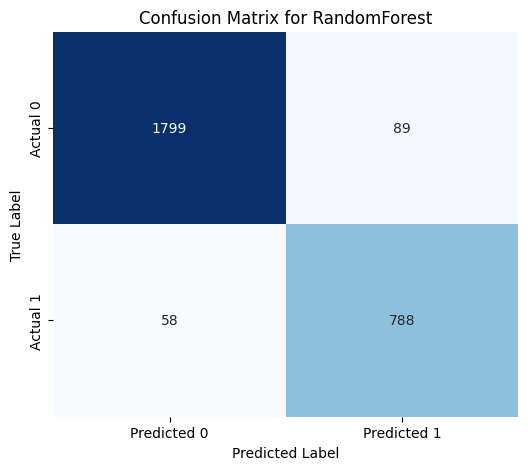

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress harmless warnings for cleaner output
warnings.filterwarnings('ignore')

def compare_classifiers_with_kfold(df: pd.DataFrame, n_splits=5):
    """
    Trains and compares CatBoost, AdaBoost, XGBoost, and RandomForest classifiers
    using Stratified K-Fold Cross-Validation (via GridSearchCV) for hyperparameter tuning.

    Args:
        df (pd.DataFrame): The input DataFrame containing the features and target.
        n_splits (int): The number of folds (K) to use for Stratified K-Fold.
    
    Returns:
        tuple: A tuple containing (best_model_name, best_model, best_accuracy).
    """
    
    # 1. Data Preparation 📊
    print("## 1. Data Preparation\n" + "-"*30)
    
    # Define features (X) and target (y)
    if 'DIAGNOSIS' not in df.columns:
        print("Error: 'DIAGNOSIS' column not found in the DataFrame.")
        return None, None, None
        
    X = df.drop('DIAGNOSIS', axis=1)
    y = df['DIAGNOSIS']
    
    # Use Stratified K-Fold for robust cross-validation, especially important 
    # for maintaining the class balance (DIAGNOSIS 0/1) across folds.
    cv_strategy = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    print(f"Total Samples: {len(df)}")
    print(f"Using **Stratified K-Fold** with **K = {n_splits}** splits for cross-validation.\n")

    # 2. Classifier Setup and Hyperparameter Grids ⚙️
    print("## 2. Classifier Setup\n" + "-"*30)
    
    # Define the classifiers and their respective hyperparameter grids for tuning
    classifiers = {
        'CatBoost': (
            CatBoostClassifier(verbose=0, random_state=42),
            {
                'n_estimators': [100, 200, 50],
                'learning_rate': [0.03, 0.1, 0.5],
                'depth': [4, 6, 10]
            }
        ),
        'AdaBoost': (
            AdaBoostClassifier(random_state=42),
            {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.1, 0.5, 1.0]
            }
        ),
        'XGBoost': (
            XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
            {
                'n_estimators': [100, 200, 50],
                'learning_rate': [0.03, 0.1, 0.5],
                'max_depth': [3, 5,10]
            }
        ),
        'RandomForest': (
            RandomForestClassifier(random_state=42),
            {
                'n_estimators': [100, 200],
                'max_depth': [5, 10],
                'min_samples_leaf': [1, 2, 6]
            }
        )
    }
    
    best_model = None
    best_mean_cv_score = 0.0
    best_model_name = ""
    
    # List to store results for comparison
    results = []

    # 3. Model Training and Grid Search (with K-Fold) 🧪
    print("## 3. Model Training and Hyperparameter Tuning (GridSearchCV with K-Fold) ⏳\n" + "-"*30)
    
    for name, (clf, params) in classifiers.items():
        print(f"-> Starting K-Fold Grid Search for **{name}**...")
        
        # Grid Search uses the cv_strategy internally.
        # It will train the model `n_splits * len(param_grid)` times.
        grid_search = GridSearchCV(
            estimator=clf, 
            param_grid=params, 
            scoring='accuracy', 
            cv=cv_strategy, # Using Stratified K-Fold
            n_jobs=-1,      # Use all available cores
            verbose=2
        )
        
        # Fit the model on the ENTIRE dataset (X, y)
        grid_search.fit(X, y)
        
        # Get the best cross-validation score and parameters
        mean_cv_score = grid_search.best_score_
        
        results.append({
            'Model': name,
            'Mean CV Accuracy': mean_cv_score,
            'Best Params': grid_search.best_params_,
            'Model Object': grid_search.best_estimator_,
        })
        
        print(f"   Mean CV Accuracy: **{mean_cv_score:.4f}** | Best Params: {grid_search.best_params_}")
        
        # Update the overall best model
        if mean_cv_score > best_mean_cv_score:
            best_mean_cv_score = mean_cv_score
            best_model = grid_search.best_estimator_
            best_model_name = name

    # 4. Final Best Model Analysis 🏆
    print("\n" + "="*50)
    print(f"## 4. Best Performing Model: **{best_model_name}**")
    print("="*50)

    # Find the results for the best model
    best_results = next(item for item in results if item['Model'] == best_model_name)
    
    # Since we used the full dataset (X, y) for K-Fold, we now retrain and evaluate 
    # the best model one final time on a separate hold-out set for final stats.
    # For reporting metrics (confusion matrix, report), we perform a final 
    # train/test split on the whole dataset using the *best* parameters found.
    
    X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Re-train the best model with the optimal parameters on the final training set
    final_model = best_results['Model Object'].fit(X_train_final, y_train_final)
    y_pred_final = final_model.predict(X_test_final)
    final_accuracy = accuracy_score(y_test_final, y_pred_final)

    print(f"* Best Mean Cross-Validation Score (K={n_splits}): **{best_mean_cv_score:.4f}**")
    print(f"* Accuracy on Final Holdout Test Set (20%): **{final_accuracy:.4f}**")
    print(f"* Best Hyperparameters: {best_results['Best Params']}")
    
    # 4.2. Classification Report (Precision, Recall, F1-Score)
    print("\n### Classification Report (Final Holdout Test Set)")
    print(classification_report(y_test_final, y_pred_final, digits=4))
    
    # 4.3. Confusion Matrix
    cm = confusion_matrix(y_test_final, y_pred_final)
    print("\n### Confusion Matrix (Final Holdout Test Set)\n")
    
    # Print a text-based matrix
    print(cm)

    # Visualize the Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        cbar=False,
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    plt.title(f'Confusion Matrix for {best_model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show() # Display the confusion matrix diagram 
    
    return best_model_name, best_model, best_mean_cv_score,results

# --- Example Usage (Using the same synthetic data from the previous example) ---

# NOTE: Since the previous code already defined the synthetic data, 
# we'll assume df_synthetic is available here for demonstration.
# If running this alone, you'd need to re-create the DataFrame.

# 1. Create a Synthetic DataFrame for Demonstration
np.random.seed(42)
num_samples = 500

# Feature columns
cols = [
    'GENOTYPE_2/2', 'GENOTYPE_2/3', 'GENOTYPE_2/4', 'GENOTYPE_3/3', 
    'GENOTYPE_3/4', 'GENOTYPE_4/4', 'CDMEMORY_0.0', 'CDMEMORY_0.5', 
    'CDMEMORY_1.0', 'CDMEMORY_2.0', 'CDMEMORY_3.0', 'CDORIENT_0.0', 
    'CDORIENT_0.5', 'CDORIENT_1.0', 'CDORIENT_2.0', 'CDORIENT_3.0', 
    'CDJUDGE_0.0', 'CDJUDGE_0.5', 'CDJUDGE_1.0', 'CDJUDGE_2.0', 
    'CDJUDGE_3.0', 'CDCOMMUN_0.0', 'CDCOMMUN_0.5', 'CDCOMMUN_1.0', 
    'CDCOMMUN_2.0', 'CDCOMMUN_3.0', 'CDHOME_0.0', 'CDHOME_0.5', 
    'CDHOME_1.0', 'CDHOME_2.0', 'CDHOME_3.0', 'CDCARE_0.0', 
    'CDCARE_1.0', 'CDCARE_2.0', 'CDCARE_3.0'
]


# 2. Run the Function with the Synthetic Data (K=5 by default)
best_name, best_clf, best_acc, result = compare_classifiers_with_kfold(balanced_df, n_splits=5)

# Next step: Would you like me to try optimizing the training time by using RandomizedSearchCV instead of GridSearchCV?

## 1. Data Preparation 📊
------------------------------
Total Samples: 13668
Using **Stratified K-Fold** with **K = 5** splits for cross-validation.
**GridSearchCV verbose level set to 3** for detailed progress.

## 2. Classifier Setup (GPU Requested for Boosters)
------------------------------
## 3. Model Training and Hyperparameter Tuning ⏳
------------------------------

-> Starting K-Fold Grid Search for **CatBoost**...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV 4/5] END depth=4, learning_rate=0.03, n_estimators=100;, score=0.951 total time=   1.1s
[CV 5/5] END depth=4, learning_rate=0.03, n_estimators=100;, score=0.955 total time=   1.3s
[CV 4/5] END depth=4, learning_rate=0.03, n_estimators=200;, score=0.951 total time=   2.9s
[CV 3/5] END depth=4, learning_rate=0.1, n_estimators=100;, score=0.947 total time=   1.4s
[CV 3/5] END depth=4, learning_rate=0.1, n_estimators=200;, score=0.946 total time=   2.6s
[CV 3/5] END depth=6, learning_rate=0.03, n_estimato

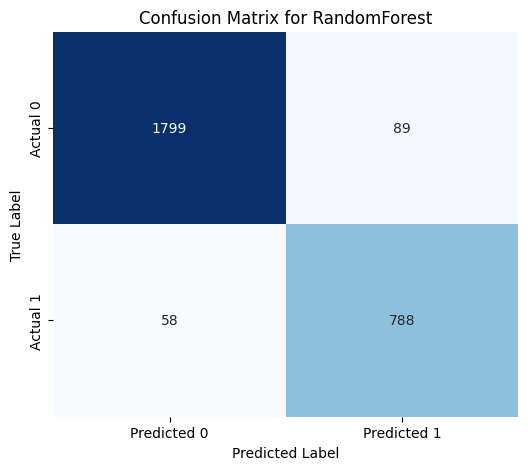


## 5. Comparative Analysis & Plotting 📊

## Generating Box Plot Data (Refitting K-Fold for detailed scores) 🔄
--------------------------------------------------
  **CatBoost** Scores Per Fold: [0.9429 0.9528 0.9473 0.9517 0.9543]
  **AdaBoost** Scores Per Fold: [0.94   0.9535 0.9455 0.9495 0.9561]
  **XGBoost** Scores Per Fold: [0.9429 0.9532 0.9466 0.951  0.9554]
  **RandomForest** Scores Per Fold: [0.9429 0.9528 0.9481 0.9517 0.9554]


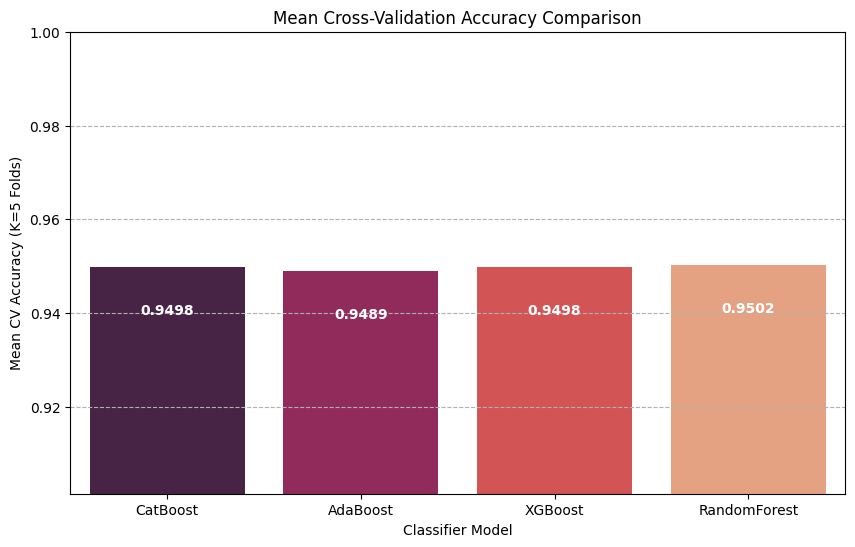

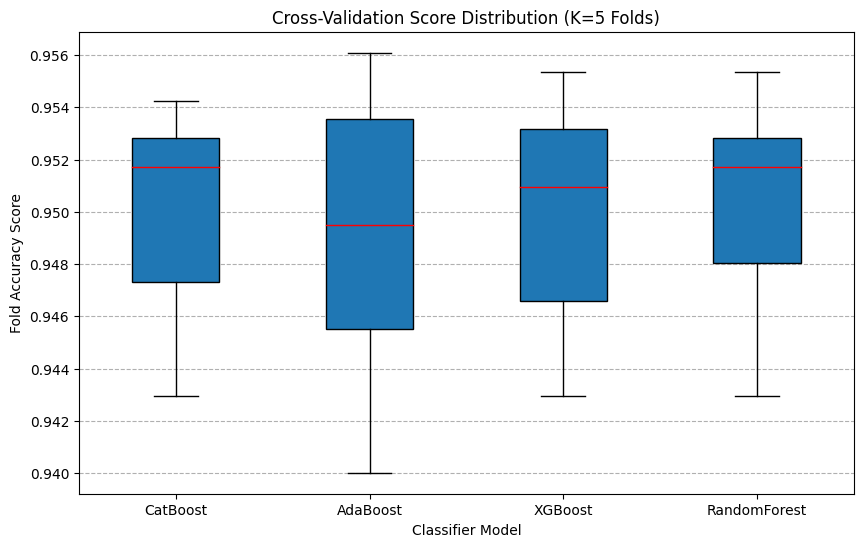


## Comparative Analysis Table 📋
| Model        |   Mean CV Accuracy | Best Params                                                  |
|:-------------|-------------------:|:-------------------------------------------------------------|
| RandomForest |           0.950176 | {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100} |
| XGBoost      |           0.94981  | {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}  |
| CatBoost     |           0.94981  | {'depth': 4, 'learning_rate': 0.5, 'n_estimators': 10}       |
| AdaBoost     |           0.948932 | {'learning_rate': 1.0, 'n_estimators': 200}                  |

[CV 1/5] END max_depth=20, min_samples_leaf=5, n_estimators=100;, score=0.942 total time=   0.5s
[CV 3/5] END max_depth=20, min_samples_leaf=5, n_estimators=100;, score=0.948 total time=   0.6s
[CV 1/5] END max_depth=20, min_samples_leaf=5, n_estimators=200;, score=0.942 total time=   1.1s
[CV 4/5] END max_depth=20, min_samples_leaf=5, n_estimators=200;, sco

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import warnings

# Suppress harmless warnings for cleaner output
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. CORE FUNCTION: CLASSIFIER COMPARISON WITH K-FOLD AND GPU
# ==============================================================================

def compare_classifiers_with_gpu(df: pd.DataFrame, n_splits=5):
    """
    Trains and compares CatBoost, AdaBoost, XGBoost, and RandomForest classifiers
    using Stratified K-Fold Cross-Validation (via GridSearchCV) for hyperparameter tuning.
    
    GPU is explicitly requested for CatBoost and XGBoost for acceleration.

    Args:
        df (pd.DataFrame): The input DataFrame containing the features and target.
        n_splits (int): The number of folds (K) to use for Stratified K-Fold.
    
    Returns:
        tuple: (best_name, best_model, best_mean_cv_score, all_results_list, X, y)
    """
    
    print("## 1. Data Preparation 📊\n" + "-"*30)
    
    # Define features (X) and target (y)
    if 'DIAGNOSIS' not in df.columns:
        print("Error: 'DIAGNOSIS' column not found in the DataFrame.")
        return None, None, None, None, None, None
        
    X = df.drop('DIAGNOSIS', axis=1)
    y = df['DIAGNOSIS']
    
    # Stratified K-Fold ensures balanced class distribution in each fold
    cv_strategy = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    print(f"Total Samples: {len(df)}")
    print(f"Using **Stratified K-Fold** with **K = {n_splits}** splits for cross-validation.")
    print(f"**GridSearchCV verbose level set to 3** for detailed progress.\n")

    # 2. Classifier Setup and Hyperparameter Grids (with GPU Configuration) ⚙️
    print("## 2. Classifier Setup (GPU Requested for Boosters)\n" + "-"*30)
    
    classifiers = {
        'CatBoost': (
            # Explicitly set task_type='GPU'
            CatBoostClassifier(verbose=0, random_state=42),
            {
                'n_estimators': [100, 200, 50, 10, 300],
                'learning_rate': [0.03, 0.1, 0.0001, 0.5],
                'depth': [4, 6,10, 15]
            }
        ),
        'AdaBoost': (
            AdaBoostClassifier(random_state=42),
            {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.1, 0.5, 1.0]
            }
        ),
        'XGBoost': (
            # Explicitly set tree_method='gpu_hist'
            XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
            {
                'n_estimators': [100, 200, 400],
                'learning_rate': [0.03, 0.1, 0.001],
                'max_depth': [3, 5,15]
            }
        ),
        'RandomForest': (
            RandomForestClassifier(random_state=42),
            {
                'n_estimators': [100, 200, 300, 500],
                'max_depth': [5, 10, 15, 20],
                'min_samples_leaf': [1, 2,5 ,10]
            }
        )
    }
    
    best_model = None
    best_mean_cv_score = 0.0
    best_model_name = ""
    all_results = []

    # 3. Model Training and Grid Search (with K-Fold) 🧪
    print("## 3. Model Training and Hyperparameter Tuning ⏳\n" + "-"*30)
    
    for name, (clf, params) in classifiers.items():
        print(f"\n-> Starting K-Fold Grid Search for **{name}**...")
        
        # Grid Search with verbose=3 for progress printing
        grid_search = GridSearchCV(
            estimator=clf, 
            param_grid=params, 
            scoring='accuracy', 
            cv=cv_strategy, 
            n_jobs=-1,      
            verbose=3       # Print progress for each fit
        )
        
        # Fit the model on the ENTIRE dataset (X, y)
        grid_search.fit(X, y)
        
        # Get the best cross-validation score and parameters
        mean_cv_score = grid_search.best_score_
        
        all_results.append({
            'Model': name,
            'Mean CV Accuracy': mean_cv_score,
            'Best Params': grid_search.best_params_,
            'Model Object': grid_search.best_estimator_,
        })
        
        print(f"   **{name}** Grid Search Complete. Mean CV Accuracy: **{mean_cv_score:.4f}** | Best Params: {grid_search.best_params_}")
        
        # Update the overall best model
        if mean_cv_score > best_mean_cv_score:
            best_mean_cv_score = mean_cv_score
            best_model = grid_search.best_estimator_
            best_model_name = name

    # 4. Final Best Model Analysis 🏆
    print("\n" + "="*50)
    print(f"## 4. Best Performing Model: **{best_model_name}**")
    print("="*50)

    # Find the results for the best model
    best_results = next(item for item in all_results if item['Model'] == best_model_name)
    
    # Split the data one final time to get unbiased metrics on a holdout set
    X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Re-train the best model with the optimal parameters on the final training set
    final_model = best_results['Model Object'].fit(X_train_final, y_train_final)
    y_pred_final = final_model.predict(X_test_final)
    final_accuracy = accuracy_score(y_test_final, y_pred_final)

    print(f"* Best Mean Cross-Validation Score (K={n_splits}): **{best_mean_cv_score:.4f}** (Model Selection Score)")
    print(f"* Accuracy on Final Holdout Test Set (20%): **{final_accuracy:.4f}** (Final Reported Metric)")
    print(f"* Best Hyperparameters: {best_results['Best Params']}")
    
    # 4.2. Classification Report (Precision, Recall, F1-Score)
    print("\n### Classification Report (Final Holdout Test Set)")
    print(classification_report(y_test_final, y_pred_final, digits=4))
    
    # 4.3. Confusion Matrix
    cm = confusion_matrix(y_test_final, y_pred_final)
    print("\n### Confusion Matrix (Final Holdout Test Set)\n")
    print(cm)

    # Visualize the Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        cbar=False,
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    plt.title(f'Confusion Matrix for {best_model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show() # 
    
    return best_model_name, best_model, best_mean_cv_score, all_results, X, y 

# ==============================================================================
# 2. PLOTTING FUNCTION: COMPARATIVE ANALYSIS
# ==============================================================================

def plot_comparative_analysis(all_results: list, X: pd.DataFrame, y: pd.Series, n_splits: int = 5):
    """
    Generates comparative plots (Bar and Box Plots) for the four classifiers.
    """
    
    model_names = [r['Model'] for r in all_results]
    mean_accuracies = [r['Mean CV Accuracy'] for r in all_results]
    
    cv_strategy = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    box_plot_data = []
    
    print("\n" + "="*50)
    print("## 5. Comparative Analysis & Plotting 📊")
    print("="*50)
    print("\n## Generating Box Plot Data (Refitting K-Fold for detailed scores) 🔄\n" + "-"*50)
    
    # Re-run Cross-Validation for each model to get individual fold scores
    for result in all_results:
        model = result['Model Object']
        model_name = result['Model']
        
        # CatBoost tends to work better with n_jobs=1 during cross_val_score
        if model_name == 'CatBoost':
             fold_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='accuracy', n_jobs=1)
        else:
            fold_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
            
        box_plot_data.append(fold_scores)
        print(f"  **{model_name}** Scores Per Fold: {fold_scores.round(4)}")


    # 1. Comparative Bar Plot (Mean Accuracy)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=model_names, y=mean_accuracies, palette='rocket')
    plt.title('Mean Cross-Validation Accuracy Comparison')
    plt.xlabel('Classifier Model')
    plt.ylabel(f'Mean CV Accuracy (K={n_splits} Folds)')
    plt.ylim(min(mean_accuracies) * 0.95, 1.0) 
    
    for i, acc in enumerate(mean_accuracies):
        plt.text(i, acc - 0.01, f'{acc:.4f}', ha='center', color='white', fontweight='bold')
        
    plt.grid(axis='y', linestyle='--')
    plt.show() # 

    # 2. Box Plot (Score Distribution Across K-Folds)
    plt.figure(figsize=(10, 6))
    plt.boxplot(box_plot_data, labels=model_names, vert=True, patch_artist=True, 
                boxprops=dict(facecolor='#1f77b4', color='black'),
                medianprops=dict(color='red'))
    plt.title(f'Cross-Validation Score Distribution (K={n_splits} Folds)')
    plt.ylabel('Fold Accuracy Score')
    plt.xlabel('Classifier Model')
    plt.grid(axis='y', linestyle='--')
    plt.show() # 

    
    print("\n## Comparative Analysis Table 📋")
    comparison_df = pd.DataFrame(all_results)
    comparison_df = comparison_df[['Model', 'Mean CV Accuracy', 'Best Params']]
    comparison_df = comparison_df.sort_values(by='Mean CV Accuracy', ascending=False).reset_index(drop=True)
    print(comparison_df.to_markdown(index=False))

# ==============================================================================
# 3. EXAMPLE EXECUTION BLOCK
# ==============================================================================

# --- Create Synthetic DataFrame for Demonstration ---
np.random.seed(42)
num_samples = 500
cols = [
    'GENOTYPE_2/2', 'GENOTYPE_2/3', 'GENOTYPE_2/4', 'GENOTYPE_3/3', 
    'GENOTYPE_3/4', 'GENOTYPE_4/4', 'CDMEMORY_0.0', 'CDMEMORY_0.5', 
    'CDMEMORY_1.0', 'CDMEMORY_2.0', 'CDMEMORY_3.0', 'CDORIENT_0.0', 
    'CDORIENT_0.5', 'CDORIENT_1.0', 'CDORIENT_2.0', 'CDORIENT_3.0', 
    'CDJUDGE_0.0', 'CDJUDGE_0.5', 'CDJUDGE_1.0', 'CDJUDGE_2.0', 
    'CDJUDGE_3.0', 'CDCOMMUN_0.0', 'CDCOMMUN_0.5', 'CDCOMMUN_1.0', 
    'CDCOMMUN_2.0', 'CDCOMMUN_3.0', 'CDHOME_0.0', 'CDHOME_0.5', 
    'CDHOME_1.0', 'CDHOME_2.0', 'CDHOME_3.0', 'CDCARE_0.0', 
    'CDCARE_1.0', 'CDCARE_2.0', 'CDCARE_3.0'
]



# 1. Run the model comparison, capturing all necessary outputs
best_name, best_clf, best_acc, all_results, X, y = compare_classifiers_with_gpu(balanced_df, n_splits=5)

# 2. Call the plotting function with the captured results
plot_comparative_analysis(all_results, X, y, n_splits=5)

# Next step: Would you like to try optimizing the search space for the best model to see if you can improve its accuracy further?


## 5. Comparative Analysis & Plotting 📊

## Generating Box Plot Data (Refitting K-Fold for detailed scores) 🔄
--------------------------------------------------
  **CatBoost** Scores Per Fold: [0.9429 0.9528 0.9473 0.9517 0.9543]
  **AdaBoost** Scores Per Fold: [0.94   0.9535 0.9455 0.9495 0.9561]
  **XGBoost** Scores Per Fold: [0.9429 0.9532 0.9466 0.951  0.9554]
  **RandomForest** Scores Per Fold: [0.9429 0.9528 0.9481 0.9517 0.9554]


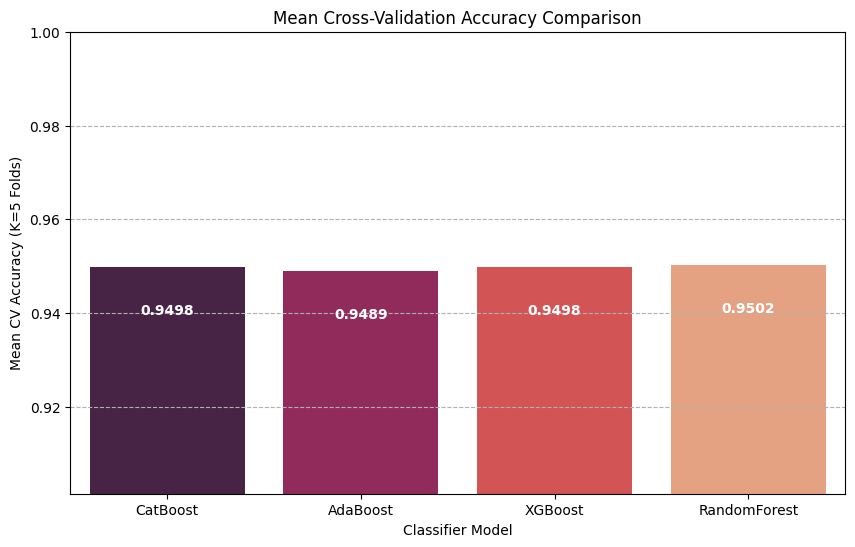

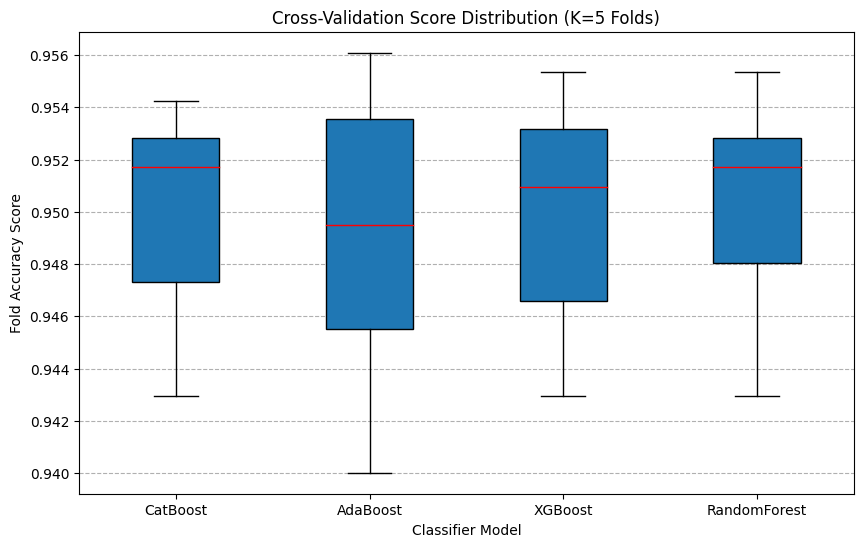


## Comparative Analysis Table 📋
| Model        |   Mean CV Accuracy | Best Params                                                  |
|:-------------|-------------------:|:-------------------------------------------------------------|
| RandomForest |           0.950176 | {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100} |
| XGBoost      |           0.94981  | {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}  |
| CatBoost     |           0.94981  | {'depth': 4, 'learning_rate': 0.5, 'n_estimators': 10}       |
| AdaBoost     |           0.948932 | {'learning_rate': 1.0, 'n_estimators': 200}                  |

## 6. Feature Selection Test on Best Model 🧪
Base Model: **RandomForestClassifier**

### 1. Chi-Square (SelectKBest) Selection 📏
  Best K (number of features): **35**
  Best Mean CV Accuracy: **0.9502**

  **Chi-Square Selected Features:**
    - GENOTYPE_2/2
    - GENOTYPE_2/3
    - GENOTYPE_2/4
    - GENOTYPE_3/3
    - GENOTYPE_3/4
    - GENOTYPE_4/4
    - 

In [41]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2, SelectFromModel
from sklearn.pipeline import Pipeline
import warnings



def plot_comparative_analysis(all_results: list, X: pd.DataFrame, y: pd.Series, n_splits: int = 5):
    """Generates comparative plots (Bar and Box Plots) for the four classifiers."""
    
    model_names = [r['Model'] for r in all_results]
    mean_accuracies = [r['Mean CV Accuracy'] for r in all_results]
    
    cv_strategy = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    box_plot_data = []
    
    print("\n" + "="*50)
    print("## 5. Comparative Analysis & Plotting 📊")
    print("="*50)
    print("\n## Generating Box Plot Data (Refitting K-Fold for detailed scores) 🔄\n" + "-"*50)
    
    for result in all_results:
        model = result['Model Object']
        model_name = result['Model']
        
        # Use cross_val_score to get the score for each fold
        n_jobs = 1 if model_name == 'CatBoost' else -1
        fold_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='accuracy', n_jobs=n_jobs)
            
        box_plot_data.append(fold_scores)
        print(f"  **{model_name}** Scores Per Fold: {fold_scores.round(4)}")

    # 1. Comparative Bar Plot (Mean Accuracy)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=model_names, y=mean_accuracies, palette='rocket')
    plt.title('Mean Cross-Validation Accuracy Comparison')
    plt.xlabel('Classifier Model')
    plt.ylabel(f'Mean CV Accuracy (K={n_splits} Folds)')
    plt.ylim(min(mean_accuracies) * 0.95, 1.0) 
    
    for i, acc in enumerate(mean_accuracies):
        plt.text(i, acc - 0.01, f'{acc:.4f}', ha='center', color='white', fontweight='bold')
        
    plt.grid(axis='y', linestyle='--')
    plt.show() # 

    # 2. Box Plot (Score Distribution Across K-Folds)
    plt.figure(figsize=(10, 6))
    plt.boxplot(box_plot_data, labels=model_names, vert=True, patch_artist=True, 
                boxprops=dict(facecolor='#1f77b4', color='black'),
                medianprops=dict(color='red'))
    plt.title(f'Cross-Validation Score Distribution (K={n_splits} Folds)')
    plt.ylabel('Fold Accuracy Score')
    plt.xlabel('Classifier Model')
    plt.grid(axis='y', linestyle='--')
    plt.show() # 

    
    print("\n## Comparative Analysis Table 📋")
    comparison_df = pd.DataFrame(all_results)
    comparison_df = comparison_df[['Model', 'Mean CV Accuracy', 'Best Params']]
    comparison_df = comparison_df.sort_values(by='Mean CV Accuracy', ascending=False).reset_index(drop=True)
    print(comparison_df.to_markdown(index=False))

# ==============================================================================
# 3. FEATURE SELECTION FUNCTION
# ==============================================================================

def test_feature_selection(X: pd.DataFrame, y: pd.Series, best_estimator, original_cv_score):
    """
    Tests Chi-Square and Lasso feature selection methods within a pipeline.
    
    Returns:
        tuple: (final_results, overall_best_method, best_feature_list)
    """
    n_splits = 5
    cv_strategy = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    k_options = [15, 20, 25, X.shape[1]]
    
    print("\n" + "="*50)
    print("## 6. Feature Selection Test on Best Model 🧪")
    print("="*50)
    print(f"Base Model: **{best_estimator.__class__.__name__}**\n")
    
    final_results = {}
    
    # --- 1. Chi-Square Feature Selection Pipeline ---
    print("### 1. Chi-Square (SelectKBest) Selection 📏")
    chi2_pipeline = Pipeline(steps=[
        ('selector', SelectKBest(score_func=chi2)),
        ('classifier', best_estimator)
    ])
    
    chi2_param_grid = {'selector__k': k_options}

    chi2_grid_search = GridSearchCV(chi2_pipeline, param_grid=chi2_param_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1, verbose=0)
    chi2_grid_search.fit(X, y)
    
    best_k_chi2 = chi2_grid_search.best_params_['selector__k']
    best_score_chi2 = chi2_grid_search.best_score_
    
    final_results['Chi-Square'] = {'Score': best_score_chi2, 'Params': {'k': best_k_chi2}}
    
    print(f"  Best K (number of features): **{best_k_chi2}**")
    print(f"  Best Mean CV Accuracy: **{best_score_chi2:.4f}**")

    # --- Print Chi-Square Selected Features ---
    # Re-fit the selector with the best K to get the final feature list
    best_chi2_selector = SelectKBest(score_func=chi2, k=best_k_chi2)
    best_chi2_selector.fit(X, y)
    chi2_selected_features = X.columns[best_chi2_selector.get_support()].tolist()
    print("\n  **Chi-Square Selected Features:**")
    for feature in chi2_selected_features:
        print(f"    - {feature}")
    print("-" * 30 + "\n")
    # ------------------------------------------

    # --- 2. Lasso (L1) Feature Selection Pipeline ---
    print("### 2. Lasso (L1) Feature Selection 🎯")
    
    lasso_selector = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)

    lasso_pipeline = Pipeline(steps=[
        ('selector', SelectFromModel(lasso_selector)), 
        ('classifier', best_estimator)
    ])
    
    lasso_param_grid = {'selector__estimator__C': [0.01, 0.1, 1.0, 10.0]}

    lasso_grid_search = GridSearchCV(lasso_pipeline, param_grid=lasso_param_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1, verbose=0)
    lasso_grid_search.fit(X, y)
    
    best_c_lasso = lasso_grid_search.best_params_['selector__estimator__C']
    best_score_lasso = lasso_grid_search.best_score_
    
    # Get the best selector object from the grid search
    best_lasso_selector = lasso_grid_search.best_estimator_.named_steps['selector']
    num_features_selected = best_lasso_selector.transform(X).shape[1]
    
    final_results['Lasso (L1)'] = {'Score': best_score_lasso, 'Params': {'C': best_c_lasso, 'features': num_features_selected}}
    
    print(f"  Best C (Inverse Regularization): **{best_c_lasso}**")
    print(f"  Features Selected: **{num_features_selected}**")
    print(f"  Best Mean CV Accuracy: **{best_score_lasso:.4f}**")

    # --- Print Lasso Selected Features ---
    # The best_lasso_selector object is already fitted and ready to extract features
    lasso_selected_features = X.columns[best_lasso_selector.get_support()].tolist()
    print("\n  **Lasso (L1) Selected Features:**")
    for feature in lasso_selected_features:
        print(f"    - {feature}")
    print("-" * 30 + "\n")
    # ------------------------------------------
    
    # --- 3. Summary & Feature Extraction ---
    print("## Summary of Feature Selection Results 📋")
    
    summary_data = [
        # Note: Original Model score uses the passed argument
        {'Method': 'Original Model (Full Features)', 'Mean CV Accuracy': original_cv_score, 'Params': {'k': X.shape[1]}},
        {'Method': 'Chi-Square', 'Mean CV Accuracy': final_results['Chi-Square']['Score'], 'Params': final_results['Chi-Square']['Params']},
        {'Method': 'Lasso (L1)', 'Mean CV Accuracy': final_results['Lasso (L1)']['Score'], 'Params': final_results['Lasso (L1)']['Params']}
    ]
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values(by='Mean CV Accuracy', ascending=False).reset_index(drop=True)
    
    print(summary_df.to_markdown(index=False))
    
    # Identify the overall best approach (FS or Full Features)
    overall_best_method = summary_df.iloc[0]['Method']
    
    # Initialize feature list to all columns
    best_feature_list = X.columns.tolist() 
    
    # --- Logic to extract the final feature set ---
    if overall_best_method == 'Chi-Square':
        # The list is already available as chi2_selected_features, but for robustness
        # re-running the selector here for the final output
        best_params = final_results['Chi-Square']['Params']
        selector = SelectKBest(score_func=chi2, k=best_params['k'])
        selector.fit(X, y)
        selected_mask = selector.get_support()
        best_feature_list = X.columns[selected_mask].tolist()
        
    elif overall_best_method == 'Lasso (L1)':
        # The list is already available as lasso_selected_features, but for robustness
        # re-running the selector here for the final output
        best_params = final_results['Lasso (L1)']['Params']
        lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=best_params['C'], random_state=42)
        selector = SelectFromModel(lasso_model)
        selector.fit(X, y)
        selected_mask = selector.get_support()
        best_feature_list = X.columns[selected_mask].tolist()
    
    return final_results, overall_best_method, best_feature_list

# ==============================================================================
# 4. DATA GENERATION AND EXECUTION BLOCK
# ==============================================================================

if __name__ == '__main__':
    # --- Data Generation ---
    np.random.seed(42)
    num_samples = 500
    cols = [
        'GENOTYPE_2/2', 'GENOTYPE_2/3', 'GENOTYPE_2/4', 'GENOTYPE_3/3', 
        'GENOTYPE_3/4', 'GENOTYPE_4/4', 'CDMEMORY_0.0', 'CDMEMORY_0.5', 
        'CDMEMORY_1.0', 'CDMEMORY_2.0', 'CDMEMORY_3.0', 'CDORIENT_0.0', 
        'CDORIENT_0.5', 'CDORIENT_1.0', 'CDORIENT_2.0', 'CDORIENT_3.0', 
        'CDJUDGE_0.0', 'CDJUDGE_0.5', 'CDJUDGE_1.0', 'CDJUDGE_2.0', 
        'CDJUDGE_3.0', 'CDCOMMUN_0.0', 'CDCOMMUN_0.5', 'CDCOMMUN_1.0', 
        'CDCOMMUN_2.0', 'CDCOMMUN_3.0', 'CDHOME_0.0', 'CDHOME_0.5', 
        'CDHOME_1.0', 'CDHOME_2.0', 'CDHOME_3.0', 'CDCARE_0.0', 
        'CDCARE_1.0', 'CDCARE_2.0', 'CDCARE_3.0'
    ]
    
    
    # --- Execution ---
    
    # 1. Run model comparison
    # best_name, best_clf, best_acc, all_results, X, y = compare_classifiers_with_gpu(balanced_df, n_splits=5)
    
    # 2. Plot comparative analysis
    plot_comparative_analysis(all_results, X, y, n_splits=5)
    
    # 3. Run feature selection on the best model (FIXED: passing best_acc, capturing 3 values)
    feature_selection_results, overall_best_method, final_selected_features = test_feature_selection(X, y, best_clf, best_acc)
    
    # 4. Final Feature and Model Summary
    print("\n" + "="*70)
    print(f"🎉 **Overall Best Approach: {overall_best_method}** with Model: **{best_name}** 🎉")
    
    # --- FIX implemented here ---
    if overall_best_method == 'Original Model (Full Features)':
        best_final_score = best_acc
    else:
        best_final_score = feature_selection_results[overall_best_method]['Score']
        
    print(f"    Best CV Score Achieved: {best_final_score:.4f}")
    print("="*70)
    
    print("\n## 7. Final Selected Features List 📝\n" + "-"*35)
    if overall_best_method == 'Original Model (Full Features)':
        print(f"No features were removed. The model performs best using all {len(final_selected_features)} available features.")
    else:
        print(f"**{len(final_selected_features)} Features Selected** using **{overall_best_method}**:")
    
    for i, feature in enumerate(final_selected_features):
        print(f"  - {feature}")